In [2]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

d:\LANGRAPH-TUTORIALS\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()

True

In [4]:
subgraph_llm = ChatGroq(model='llama-3.3-70b-versatile')
parent_llm = ChatGroq(model='llama-3.3-70b-versatile')

In [5]:
class ParentState(TypedDict):
    question: str
    answer_eng: str
    answer_urdu: str

In [7]:
def translate_node(state: ParentState):
    prompt = f'''
    Generate a translation of the following answer: {state['answer_eng']}
    '''.strip()
    response = subgraph_llm.invoke(prompt).content
    
    return {'answer_urdu': response}

In [9]:
subgraph_builder = StateGraph(ParentState)

subgraph_builder.add_node('translated_text', translate_node)

subgraph_builder.add_edge(START, 'translated_text')
subgraph_builder.add_edge('translated_text', END)

subgraph = subgraph_builder.compile()

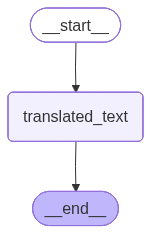

In [14]:
subgraph

In [11]:
def generate_node(state: ParentState):
    prompt = f'''
    Hi, you are a helpful assistant. Generate answer from this question {state['question']}
    '''
    result = parent_llm.invoke(prompt).content
    
    return {'answer_eng': result}

In [12]:
parent_graph = StateGraph(ParentState)

parent_graph.add_node('generate', generate_node)
parent_graph.add_node('translate', subgraph)

parent_graph.add_edge(START, 'generate')
parent_graph.add_edge('generate', 'translate')
parent_graph.add_edge('translate', END)

p_graph = parent_graph.compile()

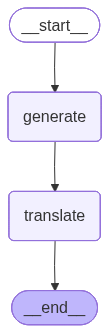

In [13]:
p_graph

In [15]:
p_graph.invoke({'question': 'waht is langgraph'})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'question': 'waht is langgraph',
 'answer_eng': "LangGraph is an innovative, open-source framework designed to simplify the development and deployment of large language models (LLMs). Developed by the team at LangGraph, the project aims to provide a unified platform for building, fine-tuning, and serving LLMs, with a focus on ease of use, flexibility, and scalability.\n\nThe key features of LangGraph include:\n\n1. **Modular Architecture**: LangGraph allows developers to break down complex language models into smaller, modular components, making it easier to develop, test, and maintain individual components.\n2. **Pre-trained Model Support**: LangGraph provides pre-trained models and fine-tuning capabilities, enabling developers to adapt models to specific tasks and domains.\n3. **Multi-Task Learning**: The framework supports multi-task learning, allowing developers to train models on multiple tasks simultaneously, which can improve overall model performance.\n4. **Distributed Trainin

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
